# Patient104_J0_0：3D MAT 文件与切片方向检查

本 notebook 读取 `data_3D_Patient104_J0_0.mat`，列出文件字段，并显示重建体数据的三个正交方向切片。

注意：另外两个方向是从重建后的 3D 体数据中生成的正交重切片（reslice），不代表另外采集了一套扫描序列。

In [1]:
from pathlib import Path
import os

# 避免某些服务器环境中的 Matplotlib 缓存目录权限问题。
os.environ.setdefault("MPLCONFIGDIR", "/tmp/neuf_matplotlib")

import matplotlib.pyplot as plt
import numpy as np
from scipy.io import loadmat, whosmat

def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "code_seg_3D").is_dir():
            return candidate
    raise FileNotFoundError("Cannot locate the NeUF project root.")

PROJECT_ROOT = find_project_root(Path.cwd())
MAT_PATH = (
    PROJECT_ROOT
    / "code_seg_3D/Pre_traitement_echo_v2/Reconstruction_3D"
    / "Patient104_J0_0/data_3D_Patient104_J0_0.mat"
)
OUTPUT_DIR = PROJECT_ROOT / "notebooks/Patient104_J0_0_orientation_check"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"MAT file:     {MAT_PATH}")
print(f"Exists:       {MAT_PATH.exists()}")

Project root: /misc/raid/zchen/Code/NeUF
MAT file:     /misc/raid/zchen/Code/NeUF/code_seg_3D/Pre_traitement_echo_v2/Reconstruction_3D/Patient104_J0_0/data_3D_Patient104_J0_0.mat
Exists:       True


## 1. 查看 MAT 文件中的字段

`whosmat` 只读取字段目录，不会先把两个大型 3D 数组全部载入内存。

In [2]:
variables = whosmat(MAT_PATH)
print("name\tshape\tdtype")
for name, shape, dtype in variables:
    print(f"{name}\t{shape}\t{dtype}")

name	shape	dtype
data_3D	(824, 1536, 1264)	uint8
data_3D_mask	(824, 1536, 1264)	uint8
metadata	(1, 1)	struct


文件中只有 `data_3D`、`data_3D_mask` 和 `metadata`，没有单独保存的额外 2D 切片字段。下面只载入图像体和元数据；掩膜与图像体同样大，本次方向检查不需要同时载入它。

In [3]:
mat = loadmat(
    MAT_PATH,
    variable_names=["data_3D", "metadata"],
    simplify_cells=True,
)
volume = mat["data_3D"]
metadata = mat["metadata"]

print(f"volume.shape = {volume.shape}")
print(f"volume.dtype = {volume.dtype}")
print(f"intensity range = [{volume.min()}, {volume.max()}]")
print(f"metadata = {metadata}")

volume.shape = (824, 1536, 1264)
volume.dtype = uint8


intensity range = [0, 254]
metadata = {'delta_X': 0.009517266, 'patient': 'Patient104', 'ref': 'Patient104_J0_0'}


## 2. 自动选择位于有效信号范围中间的切片

根据重建代码的数据含义，`axis=1` 的固定切片 `volume[:, y, :]` 是包含扫查轨迹的 X–Z 平面。`axis=0` 和 `axis=2` 的固定切片是与它正交的重切片。这里只使用轴编号，避免在缺少 DICOM 方位矩阵时武断标记为解剖学矢状/冠状/横断面。

In [4]:
def support_and_center(data: np.ndarray, axis: int):
    reduce_axes = tuple(i for i in range(data.ndim) if i != axis)
    counts = np.count_nonzero(data, axis=reduce_axes)
    support = np.flatnonzero(counts)
    if support.size == 0:
        raise ValueError(f"No non-zero signal along axis {axis}.")
    center = int(round((int(support[0]) + int(support[-1])) / 2))
    return (int(support[0]), int(support[-1])), center

supports = {}
centers = {}
for axis in range(3):
    supports[axis], centers[axis] = support_and_center(volume, axis)
    print(f"axis {axis}: signal support={supports[axis]}, selected index={centers[axis]}")

axis 0: signal support=(10, 815), selected index=412


axis 1: signal support=(342, 1173), selected index=758


axis 2: signal support=(574, 1262), selected index=918


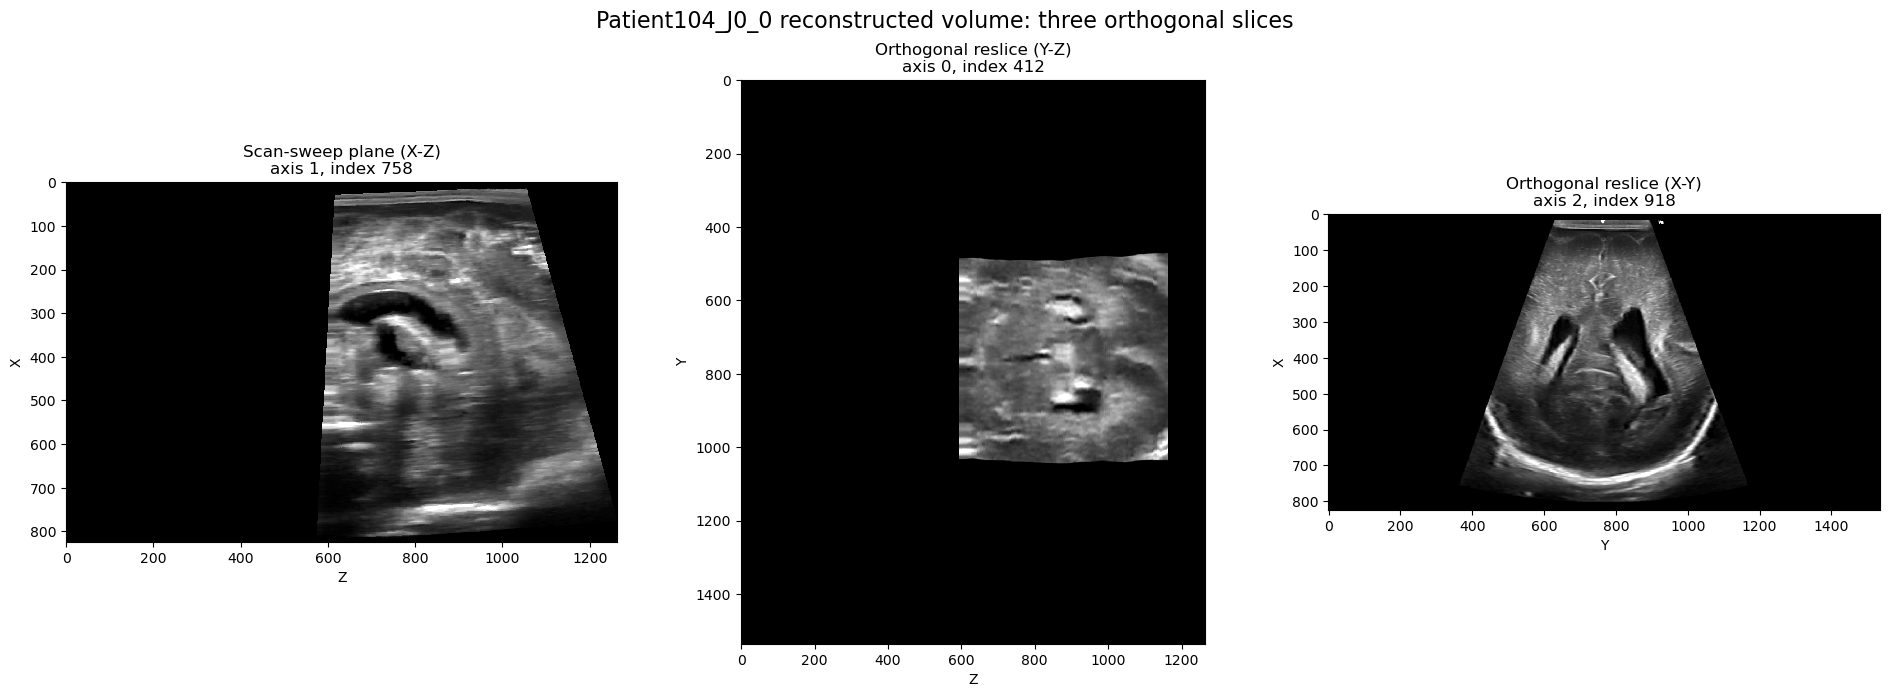

Saved overview: /misc/raid/zchen/Code/NeUF/notebooks/Patient104_J0_0_orientation_check/orthogonal_slices_overview.png


In [5]:
def get_slice(data: np.ndarray, axis: int, index: int) -> np.ndarray:
    selectors = [slice(None)] * 3
    selectors[axis] = index
    return data[tuple(selectors)]

def display_limit(image: np.ndarray, percentile: float = 99.5) -> float:
    nonzero = image[image > 0]
    return float(np.percentile(nonzero, percentile)) if nonzero.size else 1.0

slice_specs = [
    (1, centers[1], "Scan-sweep plane (X-Z)", "Z", "X", "axis1_scan_sweep.png"),
    (0, centers[0], "Orthogonal reslice (Y-Z)", "Z", "Y", "axis0_orthogonal_yz.png"),
    (2, centers[2], "Orthogonal reslice (X-Y)", "Y", "X", "axis2_orthogonal_xy.png"),
]

fig, axes = plt.subplots(1, 3, figsize=(19, 7), facecolor="white")
for ax, (axis, index, title, xlabel, ylabel, filename) in zip(axes, slice_specs):
    image = get_slice(volume, axis, index)
    vmax = display_limit(image)
    ax.imshow(image, cmap="gray", vmin=0, vmax=vmax, interpolation="nearest")
    ax.set_title(f"{title}\naxis {axis}, index {index}")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    single_fig, single_ax = plt.subplots(figsize=(9, 7), facecolor="white")
    single_ax.imshow(image, cmap="gray", vmin=0, vmax=vmax, interpolation="nearest")
    single_ax.set_title(f"{title} — axis {axis}, index {index}")
    single_ax.set_xlabel(xlabel)
    single_ax.set_ylabel(ylabel)
    single_fig.tight_layout()
    single_fig.savefig(OUTPUT_DIR / filename, dpi=160, bbox_inches="tight")
    plt.close(single_fig)

fig.suptitle("Patient104_J0_0 reconstructed volume: three orthogonal slices", fontsize=16)
fig.tight_layout()
overview_path = OUTPUT_DIR / "orthogonal_slices_overview.png"
fig.savefig(overview_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved overview: {overview_path}")

## 3. 检查结论

- `.mat` 中没有另存一张其他方向的 2D 图：只有 3D 图像体、3D 掩膜和元数据。
- 但是 3D 重建体支持其他方向的正交重切片。对当前文件，`data_3D[:, :, 918]`（axis 2）显示出清晰、完整的另一方向脑部切片；`data_3D[412, :, :]`（axis 0）也包含有效的正交切片信息。
- 因此答案是：**有可用的扫描序列方向之外的切片图像，但它来自 3D 体重切片，不是另一套独立方向的原始扫描。**
- 文件只提供一个间距标量 `delta_X = 0.009517266`，没有病人方向/仿射矩阵，所以这里只可靠地报告数组轴方向，不能仅凭本文件严格命名解剖学方位。

## 4. 查看任意轴、任意索引（可选）

修改下面的 `axis` 和 `index` 后重新运行，即可浏览其他切片。

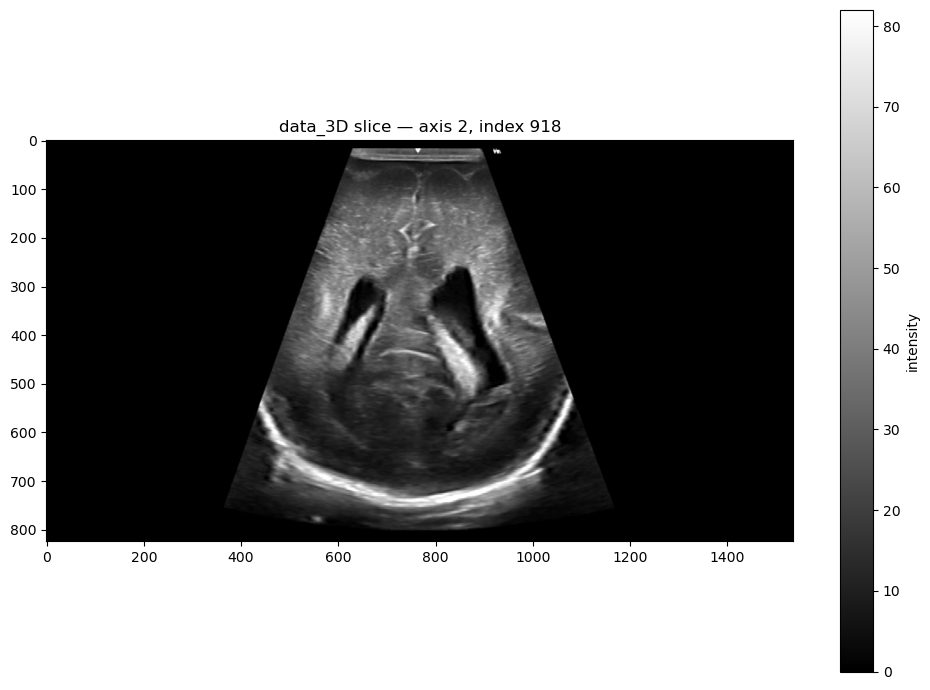

In [6]:
axis = 2
index = centers[axis]
image = get_slice(volume, axis, index)

plt.figure(figsize=(10, 7))
plt.imshow(image, cmap="gray", vmin=0, vmax=display_limit(image))
plt.title(f"data_3D slice — axis {axis}, index {index}")
plt.colorbar(label="intensity")
plt.tight_layout()
plt.show()